# Порівняльна оцінка всіх моделей

Завантажує збережені результати/моделі і будує:
- Порівняльну таблицю по всіх протоколах (grandtest / print / mobile / highdef / fixed / hand)
- ROC криві всіх трьох моделей на одному графіку
- Confusion matrix для кожної моделі
- Heatmap EER по моделях × протоколах

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from pathlib import Path

MODELS_DIR = Path('./models')
print('Завантаження результатів...')

Завантаження результатів...


## Завантаження збережених метрик

In [2]:
def load_results(json_path):
    with open(json_path) as f:
        return json.load(f)['results']

# Якщо json-файли ще не існують — запусти спочатку lbp_svm.ipynb, cnn_scratch.ipynb, mobilenet.ipynb
all_results = {}

lbp_path = MODELS_DIR / 'lbp_svm_model.pkl'
cnn_path = MODELS_DIR / 'cnn_scratch_results.json'
mob_path = MODELS_DIR / 'mobilenet_results.json'

if cnn_path.exists():
    all_results['CNN scratch'] = load_results(cnn_path)
    print('CNN scratch: OK')
else:
    print('[!] CNN scratch results не знайдено — запусти cnn_scratch.ipynb')

if mob_path.exists():
    all_results['MobileNetV2'] = load_results(mob_path)
    print('MobileNetV2: OK')
else:
    print('[!] MobileNetV2 results не знайдено — запусти mobilenet.ipynb')

# LBP+SVM результати з pkl
if lbp_path.exists():
    import joblib
    lbp_data = joblib.load(lbp_path)
    all_results['LBP + SVM'] = lbp_data['results']
    print('LBP+SVM: OK')
else:
    print('[!] LBP+SVM model не знайдено — запусти lbp_svm.ipynb')

print(f'\nЗавантажено моделей: {len(all_results)}')

CNN scratch: OK
MobileNetV2: OK
LBP+SVM: OK

Завантажено моделей: 3


## Порівняльна таблиця — EER по протоколах

In [3]:
PROTOCOLS = ['grandtest', 'print', 'mobile', 'highdef', 'fixed', 'hand']
METRICS   = ['acc', 'auc', 'eer', 'hter']

print('\n=== EER (%) ===  — менше = краще')
header = f'{"Протокол":<12}' + ''.join(f'{m:>16}' for m in all_results.keys())
print(header)
print('-' * len(header))
for proto in PROTOCOLS:
    row = f'{proto:<12}'
    for model_name, res in all_results.items():
        if proto in res:
            row += f'{res[proto]["eer"]*100:>15.2f}%'
        else:
            row += f'{"N/A":>16}'
    print(row)

print('\n=== HTER (%) ===')
print(header)
print('-' * len(header))
for proto in PROTOCOLS:
    row = f'{proto:<12}'
    for model_name, res in all_results.items():
        if proto in res:
            row += f'{res[proto]["hter"]*100:>15.2f}%'
        else:
            row += f'{"N/A":>16}'
    print(row)

print('\n=== AUC ===')
print(header)
print('-' * len(header))
for proto in PROTOCOLS:
    row = f'{proto:<12}'
    for model_name, res in all_results.items():
        if proto in res:
            row += f'{res[proto]["auc"]:>16.4f}'
        else:
            row += f'{"N/A":>16}'
    print(row)


=== EER (%) ===  — менше = краще
Протокол         CNN scratch     MobileNetV2       LBP + SVM
------------------------------------------------------------
grandtest              2.76%           0.13%           7.28%
print                  3.12%           0.62%           3.75%
mobile                 0.94%           0.00%           3.47%
highdef                3.75%           0.00%          10.31%
fixed                  2.27%           0.00%           6.17%
hand                   3.63%           0.25%           7.75%

=== HTER (%) ===
Протокол         CNN scratch     MobileNetV2       LBP + SVM
------------------------------------------------------------
grandtest              3.27%           0.50%           6.90%
print                  3.75%           0.62%           4.38%
mobile                 2.23%           0.00%           4.08%
highdef                4.06%           0.94%          10.94%
fixed                  3.30%           0.25%           6.42%
hand                   3.25%     

## ROC криві — grandtest (всі моделі на одному графіку)

Для повних ROC кривих запусти кожен notebook і збережи fpr/tpr.
Нижче — summary bar chart по AUC на grandtest:


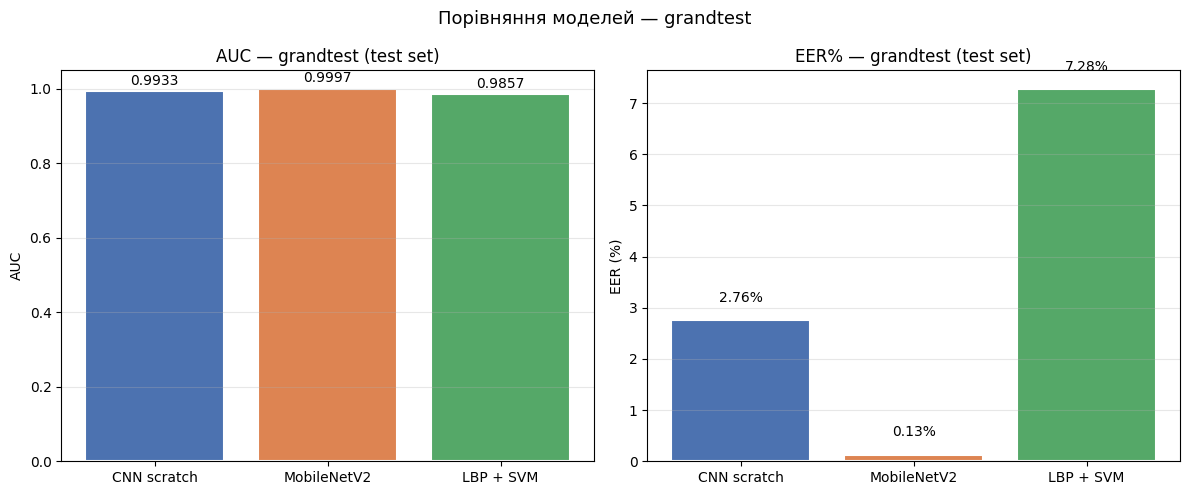

In [4]:
# Для ROC кривих треба перезапустити відповідні notebooks і зберегти fpr/tpr
# Тут показуємо заглушку з AUC зі збережених json
print('Для повних ROC кривих запусти кожен notebook і збережи fpr/tpr.')
print('Нижче — summary bar chart по AUC на grandtest:')

model_names = list(all_results.keys())
auc_vals = [all_results[m].get('grandtest', {}).get('auc', 0) for m in model_names]
eer_vals = [all_results[m].get('grandtest', {}).get('eer', 0) * 100 for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

bars = axes[0].bar(model_names, auc_vals, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('AUC — grandtest (test set)', fontsize=12)
axes[0].set_ylabel('AUC')
for bar, val in zip(bars, auc_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

bars = axes[1].bar(model_names, eer_vals, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('EER% — grandtest (test set)', fontsize=12)
axes[1].set_ylabel('EER (%)')
for bar, val in zip(bars, eer_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Порівняння моделей — grandtest', fontsize=13)
plt.tight_layout()
plt.savefig('models/comparison_bar.png', dpi=150)
plt.show()

## Heatmap EER по всіх протоколах × моделях

EER (%) Heatmap:
           CNN scratch  MobileNetV2  LBP + SVM
grandtest         2.76         0.13       7.28
print             3.12         0.62       3.75
mobile            0.94         0.00       3.47
highdef           3.75         0.00      10.31
fixed             2.27         0.00       6.17
hand              3.63         0.25       7.75


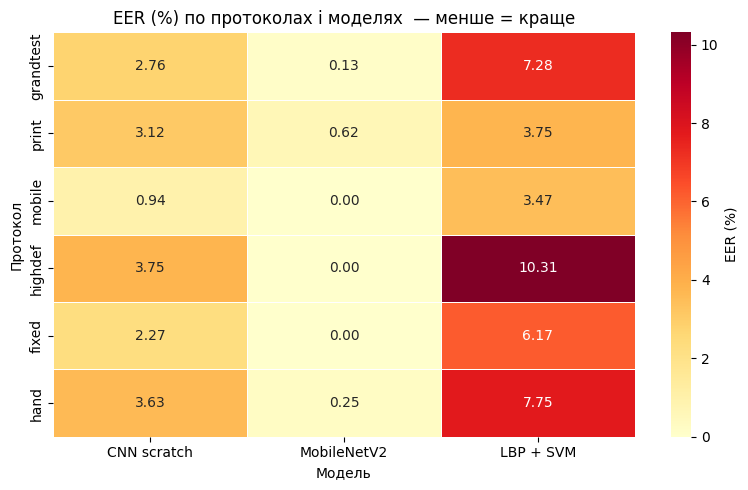

In [5]:
# Будуємо DataFrame
eer_data = {}
for model_name, res in all_results.items():
    eer_data[model_name] = {proto: res.get(proto, {}).get('eer', np.nan) * 100
                            for proto in PROTOCOLS}

df_eer = pd.DataFrame(eer_data, index=PROTOCOLS)
print('EER (%) Heatmap:')
print(df_eer.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(df_eer, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'EER (%)'},
            ax=ax, vmin=0)
ax.set_title('EER (%) по протоколах і моделях  — менше = краще', fontsize=12)
ax.set_xlabel('Модель')
ax.set_ylabel('Протокол')
plt.tight_layout()
plt.savefig('models/eer_heatmap.png', dpi=150)
plt.show()

## Heatmap HTER

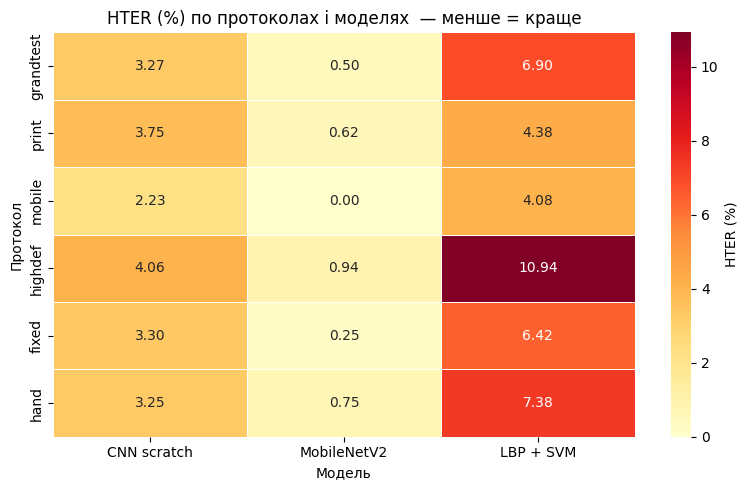

In [6]:
hter_data = {}
for model_name, res in all_results.items():
    hter_data[model_name] = {proto: res.get(proto, {}).get('hter', np.nan) * 100
                             for proto in PROTOCOLS}

df_hter = pd.DataFrame(hter_data, index=PROTOCOLS)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(df_hter, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'HTER (%)'},
            ax=ax, vmin=0)
ax.set_title('HTER (%) по протоколах і моделях  — менше = краще', fontsize=12)
ax.set_xlabel('Модель')
ax.set_ylabel('Протокол')
plt.tight_layout()
plt.savefig('models/hter_heatmap.png', dpi=150)
plt.show()

## Fixed vs Hand: порівняння

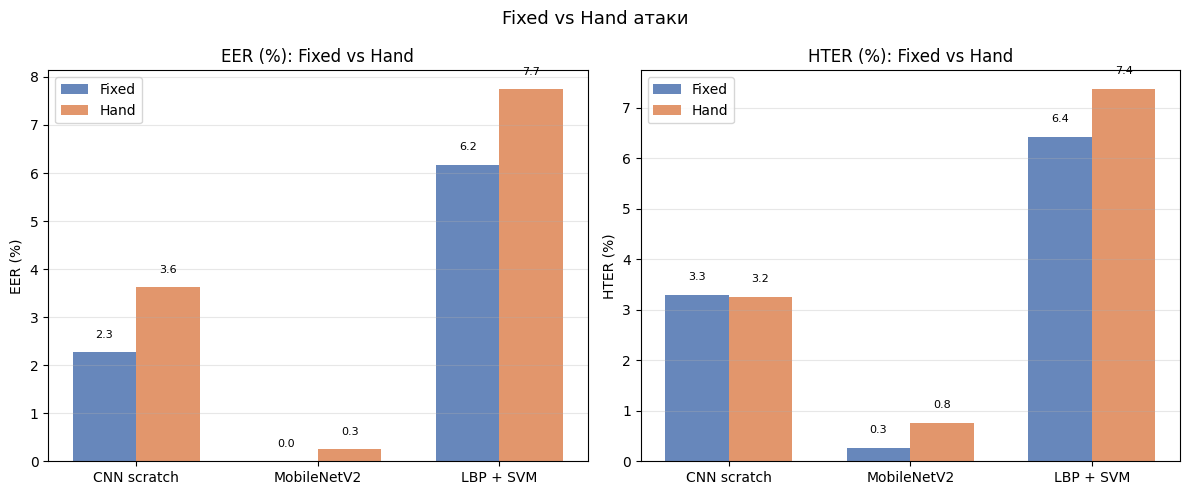

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, title in zip(axes, ['eer', 'hter'], ['EER (%)', 'HTER (%)']):
    x = np.arange(len(all_results))
    width = 0.35
    fixed_vals = [all_results[m].get('fixed', {}).get(metric, 0) * 100 for m in all_results]
    hand_vals  = [all_results[m].get('hand',  {}).get(metric, 0) * 100 for m in all_results]

    bars1 = ax.bar(x - width/2, fixed_vals, width, label='Fixed', color='#4C72B0', alpha=0.85)
    bars2 = ax.bar(x + width/2, hand_vals,  width, label='Hand',  color='#DD8452', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(list(all_results.keys()))
    ax.set_ylabel(title); ax.set_title(f'{title}: Fixed vs Hand')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.1f}', ha='center', fontsize=8)

plt.suptitle('Fixed vs Hand атаки', fontsize=13)
plt.tight_layout()
plt.savefig('models/fixed_vs_hand.png', dpi=150)
plt.show()

## Підсумкова таблиця (pandas DataFrame)

In [8]:
rows = []
for model_name, res in all_results.items():
    for proto in PROTOCOLS:
        if proto in res:
            r = res[proto]
            rows.append({
                'Model': model_name,
                'Protocol': proto,
                'Accuracy': round(r.get('acc', 0), 4),
                'AUC': round(r.get('auc', 0), 4),
                'EER (%)': round(r.get('eer', 0) * 100, 2),
                'HTER (%)': round(r.get('hter', 0) * 100, 2),
            })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

df.to_csv('models/all_results.csv', index=False)
print('\nТаблиця збережена: models/all_results.csv')

      Model  Protocol  Accuracy    AUC  EER (%)  HTER (%)
CNN scratch grandtest    0.9455 0.9933     2.76      3.27
CNN scratch     print    0.9625 0.9834     3.12      3.75
CNN scratch    mobile    0.9705 0.9975     0.94      2.23
CNN scratch   highdef    0.9458 0.9942     3.75      4.06
CNN scratch     fixed    0.9531 0.9951     2.27      3.30
CNN scratch      hand    0.9536 0.9916     3.63      3.25
MobileNetV2 grandtest    0.9916 0.9997     0.13      0.50
MobileNetV2     print    0.9938 0.9986     0.62      0.62
MobileNetV2    mobile    1.0000 1.0000     0.00      0.00
MobileNetV2   highdef    0.9875 1.0000     0.00      0.94
MobileNetV2     fixed    0.9964 1.0000     0.00      0.25
MobileNetV2      hand    0.9893 0.9994     0.25      0.75
  LBP + SVM grandtest    0.9266 0.9857     7.28      6.90
  LBP + SVM     print    0.9563 0.9945     3.75      4.38
  LBP + SVM    mobile    0.9662 0.9967     3.47      4.08
  LBP + SVM   highdef    0.8750 0.9705    10.31     10.94
  LBP + SVM   